### To Run in Colab please execute the following codes

In [ ]:
'''

# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

'''

In [ ]:
'''

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

ratanasovann_food_101_path = kagglehub.dataset_download('ratanasovann/food-101')

print('Data source import complete.')

'''

# 0. Context

The goal of this notebook is to analyse pre-trained CNN models architecture and compare performance on Food101 dataset. The CNN models analyzed are: GoogleLeNet, MobileNetv3 (Large), ResNet50.

The Dataset used is Food101 dataset. This dataset consists of 101 food categories, with 101,000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. All images were rescaled to have a maximum side length of 512 pixels.

This notebook is created on Kaggle. Kaggle provides GPU accelerators up 30 hours per week, which make it ideal to perform transform learning for 3 models in a single notebook (doesn't get cut-off every 4 hours like GoogleColabs :D )


# 1. Import Required Packages

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive
import torchvision.models as models
from pathlib import Path
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torchvision.transforms import InterpolationMode
import time # Import time to track each model's training time


# 2. Download Dataset

In [2]:
# ✅ Updated path to the dataset images folder on Kaggle
dataset_path = "/kaggle/input/food-101/food-101/images"

# Function to count images in each class directory
def count_images(dataset_path):
    total_images = 0
    for class_name in sorted(os.listdir(dataset_path)):  # Sorting for consistent output
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):  # Ensure it's a directory
            num_images = len(os.listdir(class_path))
            print(f"{class_name}: {num_images} images")
            total_images += num_images
    print(f"\nTotal images in dataset: {total_images}")

# Run the function
count_images(dataset_path)

apple_pie: 1000 images
baby_back_ribs: 1000 images
baklava: 1000 images
beef_carpaccio: 1000 images
beef_tartare: 1000 images
beet_salad: 1000 images
beignets: 1000 images
bibimbap: 1000 images
bread_pudding: 1000 images
breakfast_burrito: 1000 images
bruschetta: 1000 images
caesar_salad: 1000 images
cannoli: 1000 images
caprese_salad: 1000 images
carrot_cake: 1000 images
ceviche: 1000 images
cheese_plate: 1000 images
cheesecake: 1000 images
chicken_curry: 1000 images
chicken_quesadilla: 1000 images
chicken_wings: 1000 images
chocolate_cake: 1000 images
chocolate_mousse: 1000 images
churros: 1000 images
clam_chowder: 1000 images
club_sandwich: 1000 images
crab_cakes: 1000 images
creme_brulee: 1000 images
croque_madame: 1000 images
cup_cakes: 1000 images
deviled_eggs: 1000 images
donuts: 1000 images
dumplings: 1000 images
edamame: 1000 images
eggs_benedict: 1000 images
escargots: 1000 images
falafel: 1000 images
filet_mignon: 1000 images
fish_and_chips: 1000 images
foie_gras: 1000 image

## [2.1] Data Preperation

### [2.1.1] Define Transformation

In [3]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


### [2.1.2] Split the dataset into Train and test using Food101 (internally load the split done in meta)

In [4]:
from torchvision.datasets import Food101

# Updated paths for the Kaggle environment
train_dataset = Food101(root='/kaggle/input/food-101', split='train', transform=transform, download=False)
test_dataset = Food101(root='/kaggle/input/food-101', split='test', transform=transform, download=False)

In [5]:
print("Number of samples in train set:", len(train_dataset))
print("Classes:", train_dataset.classes)
print("Class to index mapping:", train_dataset.class_to_idx)

Number of samples in train set: 75750
Classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich

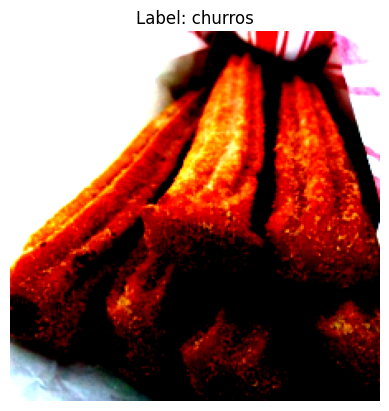

In [6]:
# Get a sample (image, label) from the training set
image, label = train_dataset[1]

# If using transforms, the image tensor is likely in [C, H, W] format.
# Convert it to [H, W, C] for matplotlib:
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {train_dataset.classes[label]}")
plt.axis("off")
plt.show()

### [2.1.3] Load into Dataloader

In [7]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=50, shuffle=True)  # Shuffle training data
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=50, shuffle=False)

In [8]:
print(f"Size of train_loader: {len(train_loader)}")
print(f"Size of test_loader: {len(test_loader)}")

Size of train_loader: 1515
Size of test_loader: 505


The number of training images is 750 per class so 750 * 101 = 75750
The number of Testing images is 250 per class so 250 * 101 = 25250

Since we specify 50 batch size train_loader: 75750/50 = 1515

Hence, the size above should be correct

### [2.1.4] View images and Class

In [9]:
# Function to display images in a grid along with their class labels.
def show_images(images, labels, class_labels):

    # Calculate the number of images and rows required
    num_images = len(images)
    num_rows = (num_images + 4) // 5    # Arrange 5 images per row

    # Create a figure and axes for subplots
    fig, axes = plt.subplots(num_rows, 5, figsize=(15, 3 * num_rows))
    axes = axes.flatten()               # Flatten axes array for easier iteration

    # Loop through the images and corresponding labels
    for i, (image, label) in enumerate(zip(images, labels)):

        image = image.numpy().transpose((1, 2, 0))      # Convert from tensor to NumPy array and change the channel dimension
        mean = np.array([0.485, 0.456, 0.406])          # Mean values used for normalization
        std = np.array([0.229, 0.224, 0.225])           # Standard deviation values used for normalization
        image = std * image + mean                      # Denormalize the image
        image = np.clip(image, 0, 1)                    # Clip pixel values to range [0, 1]

        # Display the image and set its title as the class label
        axes[i].imshow(image)                   # Display the image
        axes[i].set_title(class_labels[label])  # Set the title of the subplot as the class label
        axes[i].axis('off')                     # Hide axis

    # Hide empty subplots
    for j in range(num_images, num_rows * 5):
        axes[j].axis('off')  # Hide axis for empty subplots

    # Adjust layout and display the plot
    plt.tight_layout()      # Adjust the layout of subplots
    plt.show()              # Display the plot

In [10]:
full_dataset = datasets.ImageFolder(root='/kaggle/input/food-101/food-101/images', transform=transform)
class_labels = full_dataset.classes   # Get the class labels

In [ ]:
# Get one image from each class
images, labels = [], []                   # Initialize lists to store images and labels
classes_found = set()                     # Keep track of classes already found
for img, lbl in train_loader:             # Iterate through the training loader
    for image, label in zip(img, lbl):    # Iterate through each image and label in the batch

        # Check if we have already found an image from this class
        if class_labels[label.item()] not in classes_found:
            images.append(image)                                # Add the image to the list of images
            labels.append(label)                                # Add the label to the list of labels
            classes_found.add(class_labels[label.item()])       # Add the class to the set of found classes

    # If we have found one image from each class, stop looping
    if len(images) == len(class_labels):
        break

# Display one image from each class with 5 images per row
show_images(images, labels, class_labels)         # Call the show_images function to display the images

# 3. Load Model

## [3.1] Google V Net

In [12]:
# Load GoogLeNet
googlenet = models.googlenet(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth
100%|██████████| 49.7M/49.7M [00:00<00:00, 189MB/s]


In [13]:
# Freeze all layers for param in googlenet.parameters()
for param in googlenet.parameters():
    param.requires_grad = False

In [14]:
# Check out the architecture
print(googlenet)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

### [3.1.1] Replace the model head with 3 dully connected layer



*  The 1st layer reduce Googlevnet 1024 in_features to lower dimension, 256 neurons.
*  Then followed by a ReLu activation function to introduce non-linearity

*   2nd layer further compress 256 neurons to 128 neurons. Followed by another ReLu activation function
*   3d layer is the output later with final output being 101 = 101 class.





In [15]:
# Check original fc input size
in_features = googlenet.fc.in_features

In [16]:
# Replace model head with your own 3-layer MLP
googlenet.fc = nn.Sequential(
    nn.Linear(in_features, 256), # - A Linear layer reducing from 1024 features to 256
    nn.ReLU(),                   # - A ReLU activation function
    nn.Linear(256, 128),         # - A Linear layer reducing from 256 features to 128
    nn.ReLU(),                   # - A ReLU activation functi
    nn.Linear(128, 101),         # - A final Linear layer reducing from 128 to 101 (for 101 class)
)

In [17]:
print(googlenet)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

### [3.1.2] Train and Evaluate model

In [18]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
# Define loss funtion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(googlenet.parameters(), lr=0.00001)

In [20]:
# Move model to device
googlenet.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [21]:
# Initialize lists to store epoch-wise values
train_losses = []
train_accuracies = []

num_epochs = 10

# Start timing
start_time = time.time()

# Training loop
for epoch in range(num_epochs):
    googlenet.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = googlenet(inputs)

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(logits, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_accuracy = correct_train / total_train

    train_losses.append(epoch_train_loss)
    train_accuracies.append(train_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

# End timing
end_time = time.time()
elapsed_time = end_time - start_time

print(f'\nTotal Training Time: {elapsed_time // 60:.0f} minutes and {elapsed_time % 60:.2f} seconds')


Epoch [1/10], Train Loss: 4.6003, Train Accuracy: 0.0210
Epoch [2/10], Train Loss: 4.5154, Train Accuracy: 0.0710
Epoch [3/10], Train Loss: 4.3593, Train Accuracy: 0.1203
Epoch [4/10], Train Loss: 4.1589, Train Accuracy: 0.1554
Epoch [5/10], Train Loss: 3.9536, Train Accuracy: 0.1832
Epoch [6/10], Train Loss: 3.7708, Train Accuracy: 0.2006
Epoch [7/10], Train Loss: 3.6181, Train Accuracy: 0.2156
Epoch [8/10], Train Loss: 3.4941, Train Accuracy: 0.2297
Epoch [9/10], Train Loss: 3.3890, Train Accuracy: 0.2429
Epoch [10/10], Train Loss: 3.3012, Train Accuracy: 0.2539

Total Training Time: 77 minutes and 37.76 seconds


In [22]:
# Evaluate the model on test set
correct = 0
total = 0

# Switch to evaluation mode and disable gradient calculation.
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = googlenet(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f'Accuracy on test set: {test_accuracy:.2%}')

Accuracy on test set: 1.39%


## [3.2] Mobilenet_v3:

### [3.2.1] Freeze and replace model head

In [23]:
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

weights = MobileNet_V3_Large_Weights.DEFAULT
mobilenet_v3_large = mobilenet_v3_large(weights=weights)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 148MB/s]


In [24]:
# Freeze all layers for param in mobilenet_small.parameters()
for param in mobilenet_v3_large.parameters():
    param.requires_grad = False

In [25]:
mobilenet_v3_large

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [26]:
# Check original fc input size
in_features = mobilenet_v3_large.classifier[0].in_features

In [27]:
in_features

960

In [28]:
# Replace model head with your own 3-layer MLP
mobilenet_v3_large.classifier = nn.Sequential(
    nn.Linear(in_features, 256), # - A Linear layer reducing from 1024 features to 256
    nn.ReLU(),                   # - A ReLU activation function
    nn.Linear(256, 128),         # - A Linear layer reducing from 256 features to 128
    nn.ReLU(),                   # - A ReLU activation functi
    nn.Linear(128, 101),         # - A final Linear layer reducing from 128 to 101 (for 101 class)
)

### [3.2.2] Model training and Evaluation

In [29]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
# Define loss funtion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet_v3_large.parameters(), lr=0.00001)

In [31]:
mobilenet_v3_large = mobilenet_v3_large.to(device)

In [32]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
# Start timing
start_time = time.time()

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    mobilenet_v3_large.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer.zero_grad()                                   # Reset gradients to zero
        outputs = mobilenet_v3_large(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

       # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy

    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
    
# End timing
end_time = time.time()
elapsed_time = end_time - start_time

print(f'\nTotal Training Time: {elapsed_time // 60:.0f} minutes and {elapsed_time % 60:.2f} seconds')




Epoch [1/10], Train Loss: 4.5817, Train Accuracy: 0.0345
Epoch [2/10], Train Loss: 4.4077, Train Accuracy: 0.1082
Epoch [3/10], Train Loss: 4.1258, Train Accuracy: 0.1732
Epoch [4/10], Train Loss: 3.8290, Train Accuracy: 0.2111
Epoch [5/10], Train Loss: 3.5726, Train Accuracy: 0.2380
Epoch [6/10], Train Loss: 3.3679, Train Accuracy: 0.2617
Epoch [7/10], Train Loss: 3.2091, Train Accuracy: 0.2820
Epoch [8/10], Train Loss: 3.0804, Train Accuracy: 0.3000
Epoch [9/10], Train Loss: 2.9750, Train Accuracy: 0.3172
Epoch [10/10], Train Loss: 2.8883, Train Accuracy: 0.3294

Total Training Time: 74 minutes and 6.69 seconds


In [33]:
# Evaluate the model on test set
correct = 0
total = 0

# Switch to evaluation mode and disable gradient calculation.
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet_v3_large(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f'Accuracy on test set: {test_accuracy:.2%}')

Accuracy on test set: 1.77%


## [3.3] ResNet 50:

### [3.3.1] Freeze and replace model head

In [34]:
transform = transforms.Compose([
    transforms.Resize(232, interpolation=InterpolationMode.BILINEAR), # ResNet preprocess use 232 resize
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [35]:
from torchvision.datasets import Food101

# Updated paths for the Kaggle environment
train_dataset = Food101(root='/kaggle/input/food-101', split='train', transform=transform, download=False)
test_dataset = Food101(root='/kaggle/input/food-101', split='test', transform=transform, download=False)

In [36]:
# Load pre-trained ResNet50 model
resnet50 = models.resnet50(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


In [37]:
# Freeze layer
for param in resnet50.parameters():
    param.requires_grad = False

In [38]:
resnet50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [39]:
in_features = resnet50.fc.in_features

In [40]:
# Replace model head with your own 3-layer MLP
resnet50.fc = nn.Sequential(
    nn.Linear(in_features, 256), # - A Linear layer reducing from 1024 features to 256
    nn.ReLU(),                   # - A ReLU activation function
    nn.Linear(256, 128),         # - A Linear layer reducing from 256 features to 128
    nn.ReLU(),                   # - A ReLU activation functi
    nn.Linear(128, 101),         # - A final Linear layer reducing from 128 to 101 (for 101 class)
)

### [3.3.2] Train and Evaluate model

In [41]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [42]:
# Define loss funtion and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.parameters(), lr=0.00001)

In [43]:
# Move model to device
resnet50.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [44]:
# Initialize lists to store epoch-wise values
train_losses = []       # List to store training losses
train_accuracies = []   # List to store training accuracies
# Start timing
start_time = time.time()

# Training loop
num_epochs = 10                     # Number of epochs for training
for epoch in range(num_epochs):

    # Training
    resnet50.train()             # Set the model to training mode
    running_train_loss = 0.0        # Accumulate training loss
    correct_train = 0               # Count correct predictions in training
    total_train = 0                 # Total training samples processed

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)   # Move data to GPU if available
        optimizer.zero_grad()                                   # Reset gradients to zero
        outputs = resnet50(inputs)                           # Forward pass

        # Unpack logits if model returns tuple
        if isinstance(outputs, tuple):
            logits = outputs[0]
        else:
            logits = outputs

        loss = criterion(logits, labels)                        # Calculate loss
        loss.backward()                                         # Backward pass
        optimizer.step()                                        # Update model parameters

        running_train_loss += loss.item() * inputs.size(0)      # Update accumulated loss
        _, predicted = torch.max(logits, 1)                     # Get predicted class indices
        total_train += labels.size(0)                           # Update total count
        correct_train += (predicted == labels).sum().item()     # Count correct predictions

       # Calculate epoch-wise training loss and accuracy
    epoch_train_loss = running_train_loss / len(train_loader.dataset)     # Average training loss
    train_accuracy = correct_train / total_train                          # Training accuracy



    # Print progress for the current epoch.
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

# End timing
end_time = time.time()
elapsed_time = end_time - start_time

print(f'\nTotal Training Time: {elapsed_time // 60:.0f} minutes and {elapsed_time % 60:.2f} seconds')

Epoch [1/10], Train Loss: 4.5204, Train Accuracy: 0.0695
Epoch [2/10], Train Loss: 4.1985, Train Accuracy: 0.1799
Epoch [3/10], Train Loss: 3.7850, Train Accuracy: 0.2454
Epoch [4/10], Train Loss: 3.4372, Train Accuracy: 0.2829
Epoch [5/10], Train Loss: 3.1845, Train Accuracy: 0.3120
Epoch [6/10], Train Loss: 2.9983, Train Accuracy: 0.3356
Epoch [7/10], Train Loss: 2.8585, Train Accuracy: 0.3541
Epoch [8/10], Train Loss: 2.7468, Train Accuracy: 0.3680
Epoch [9/10], Train Loss: 2.6552, Train Accuracy: 0.3815
Epoch [10/10], Train Loss: 2.5797, Train Accuracy: 0.3959

Total Training Time: 93 minutes and 12.45 seconds


In [45]:
# Evaluate the model on test set
correct = 0
total = 0

# Switch to evaluation mode and disable gradient calculation.
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f'Accuracy on test set: {test_accuracy:.2%}')

Accuracy on test set: 1.82%


# 4. Comparing Model's Architecture and Performance

### GooleLeNet's Architecture:

**1. Initial Convolution and Pooling Layers**

* conv1: 7x7 Conv layer with 64 filters, stride 2 (for downsampling), followed by BatchNorm.

* maxpool1: 3x3 MaxPooling, stride 2.

* conv2: 1x1 Conv with 64 filters.

* conv3: 3x3 Conv with 192 filters, padding 1 (preserve spatial size).

* maxpool2: Another 3x3 MaxPool, stride 2.

**2. Inception Modules These blocks extract spatial features at different scales by combining:**

* 1x1 conv (for dimensionality reduction),

* 3x3 conv (medium receptive field),

* 5x5 conv (large receptive field),

* and a 3x3 max-pooling layer followed by a 1x1 conv.

Each block has four branches:

* branch1: 1x1 conv.

* branch2: 1x1 conv → 3x3 conv.

* branch3: 1x1 conv → 5x5 conv (or in some blocks, another 3x3).

* branch4: 3x3 max pool → 1x1 conv.



**3. Pooling Layers between Inception Blocks**

* maxpool3: 3x3 MaxPool, stride 2 — reduces spatial dimensions after inception3b.

In GoogleVNet there are **9 inceptions block** and intuitiely the inception blocks works as follows:


In [46]:
'''
        ┌───────────── 1x1 Conv ─────────────┐
        │                                    │
        ├───────────── 3x3 Conv ─────────────┤
        │                                    │
Input ──┼───────────── 5x5 Conv ─────────────┤── Concatenate (depth-wise)
        │                                    │
        └────── 3x3 MaxPool → 1x1 Conv ──────┘

'''

'\n        ┌───────────── 1x1 Conv ─────────────┐\n        │                                    │\n        ├───────────── 3x3 Conv ─────────────┤\n        │                                    │\nInput ──┼───────────── 5x5 Conv ─────────────┤── Concatenate (depth-wise)\n        │                                    │\n        └────── 3x3 MaxPool → 1x1 Conv ──────┘\n\n'

The idea is a multi-scale feature extraction by having all 4 blocks operate on the same input, but they process it at different scales and types of operations:

* Some look for fine details.

* Some look for larger patterns.

* Some smooth out and compress the signal.

This creates a richer feature representation when all branches are concatenated together.



### MobileV3 (Large):

MobileV3 is designed for mobile and edge devices that demands more efficiency and lower computational cost. Mobilev3 main architecture consists of:

**1.Conv2dNormActivation:**
* Convolution: A 2D convolution that applies a set of filters to the input image.

* BatchNorm: Normalization that ensures the network is more stable and converges faster.

* Activation: ReLU (or Hardswish in some layers) that introduces non-linearity to help the network learn more complex patterns.

**2. InvertedResidual:**
* The very first inverted block the first layer applies a **depthwise convolution** with 16 channels, using a 3x3 kernel and groups=16, followed by batch norm and ReLu.
* The second layer applies a **pointwise convolution** (1x1) to reduce or maintain the channel size.

* The subsequent Inverted blocks follows this pattern: use a **1×1 pointwise convolution** to increase channel depth (e.g., from 16 → 64); **Depthwise convolution** (apply spatial filtering (3×3) separately on each channel); use another **1×1 pointwise convolution** to reduce depth back down.

The idea is when you expand the number of chanels, you're increasing the model capacity to capture complex features. After running deepwise convolution and learning features in a high-dimensional space, many of those features are redundant. Hence, we use a 1×1 convolution to project them back to a lower-dimensional space. This process is reapeated when we want to go deeper or extract more complex features.

* **Squeeze-and-Excitation (SE) Blocks:** this is used in some layers to recalibrate channel-wise feature responses. It helps the network focus on more important features by adjusting the importance of channels

**3. Pooling:**
* No explicit pooling layer but the convolution operations with strides (e.g., stride=2 in the 3x3 convolution) serve to downsample the feature maps, effectively acting as pooling



### Resnet 50

Instead of learning the full feature mapping, Resnet is designed to learn from residuals (the change needed from input and not the entire transformation). ResNet 50 has 50 layers, which provide a balance between training time and accuracy compared to deeper model like Resnet101. Its architecture compose of:

**1. Initial Convolution Layer and Pooling:**
* Similar to GoogleLeNet 7x7 convolution to capture broad spatial features, followed by max pooling to reduce resolution.

**2. Bottleneck Blocks:**

* Conv2_x: 1st Residual Block Set (3 Bottleneck Blocks)

* 1×1 conv (64) → 3×3 conv (64) → 1×1 conv (256)

* Shortcut: 1×1 conv (to match 256 channels in 1st block)

* Output size: 56×56×256

* Repeated 3 times

* Conv3_x: 2nd Residual Block Set (4 Bottleneck Blocks)

* 1×1 conv (128) → 3×3 conv (128) → 1×1 conv (512)

* Shortcut projection in 1st block (1×1 conv to match 512)

* First block downsamples (stride=2) → output: 28×28×512

* Repeated 4 times

* Conv4_x: 3rd Residual Block Set (6 Bottleneck Blocks)

* 1×1 conv (256) → 3×3 conv (256) → 1×1 conv (1024)

* Shortcut projection in 1st block

* First block downsamples → output: 14×14×1024

* Repeated 6 times

* Conv5_x: 4th Residual Block Set (3 Bottleneck Blocks)

* 1×1 conv (512) → 3×3 conv (512) → 1×1 conv (2048)

* Shortcut projection in 1st block

* First block downsamples → output: 7×7×2048

* Repeated 3 times

**Understandaing Bottleneck blocks**

Each Bottleneck bocks compose of 1×1 conv → 3×3 conv → 1×1 conv. The main idea behind Resnet is skip connections--learning from residuals which allows the gradient to flow through bypassing its ReLu during backward propagation. This enable deeper layer to be constructed, creating a richer model. 

* First set of group has 3 bottlenecks
* Second set of group has 4 bottlenecks
* Third has 6
* Fourth has 3

The increasing number of bottleneck blocks in the middle stages (Conv3_x and Conv4_x) allows the network to learn more complex features as the spatial dimensions of the feature maps decrease.

The con_3 layer of each block's always match the input of con_1, with the exception of the first block (Bottleneck 0). The intuition behind this structure is as follows:

* 1×1 conv (e.g 256 -> 64): reduce number of channels--like choosing what’s important to keep
* 3x3 conv (e.g 64 -> 64): learns spatial relationships (edges, textures) efficiently
* 1x1 conv (e.g 64 -> 256): ensures shape compatibility with the original input for the residual connection -- kind of Learns linear combinations across channels.

Heres, where the magic happens. Because the input and output have the same shape, we can represent the final output after Relu as y = ReLu(f(x) + x), the original input plus some residual. So, when we run bacnkward proporgation, we encourage the model to learn what x (residual) is. So the gradient can flow back by adjusting x instead of only the whole f(x) which are, conv + BN + ReLU stack, when needed. The model can skip! 

Block 0 of each group is special — it does two big things:

✅ Downsamples (spatial: halves the height/width)

✅ Increases channel depth (e.g., from 256 → 512)

Block 0’s conv3 sets the new resolution and depth for the group.
It must expand, even if conv1 didn’t match — and the shortcut path will be reshaped (downsampled) to match it too.

So, block 0 expand to capture more representation of the feature and downsample is called to match the new expanded output with input to enable the skipping process.


**3.Global Average Pooling Layer:**

Pooling size: 7×7 → output: 1×1×2048

Fully Connected Layer

Dense layer with 1000 units (for ImageNet classification)

Softmax activation → output: 1000 class probabilities

### Model transferlearning evaluatiuon:

* The best performing model from transform learning with only 10 Epochs is ResNet50. It also has the longest trainign time (93min)
* The fastest model is MobileVNet (large) which has similar performance to GoogleLeNet, but train a bit quicker (74 min)
* Moving forwards to part B we will use ResNet50 to fine-tune as it gives the best result.